<a href="https://colab.research.google.com/github/Dexter0013/Deepraj-Singha-6th-Sem-CSE-Data-Mining-Assignments/blob/main/3.%20KNN%20on%20IRIS%20Dataset/KNN%20on%20IRIS%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (120, 4)
Testing set shape: (30, 4)


### K-Nearest Neighbors Model

In [20]:
# Updating the KNN model with the optimal k value found from the graph
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)

print("KNN Training Complete with k=17.")

KNN Training Complete with k=17.


### Final Model Evaluation and Confusion Matrix

Test Accuracy: 0.9667

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



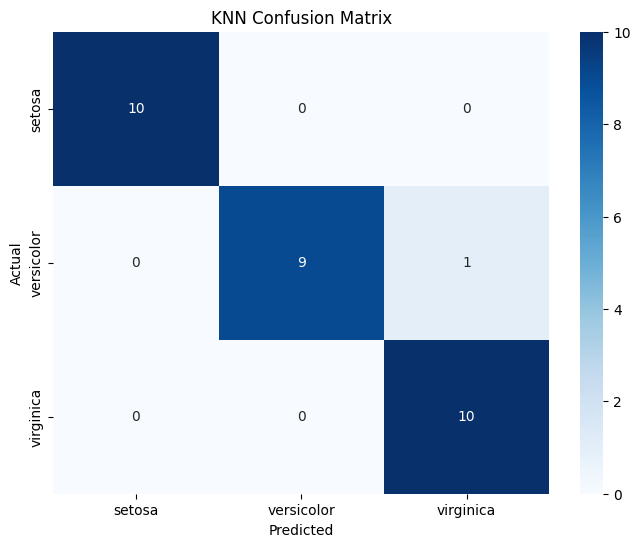

In [21]:
# Predict using the KNN
y_pred = knn.predict(X_test_scaled)

# Accuracy
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

# Classification Report
print("KNN Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()